In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

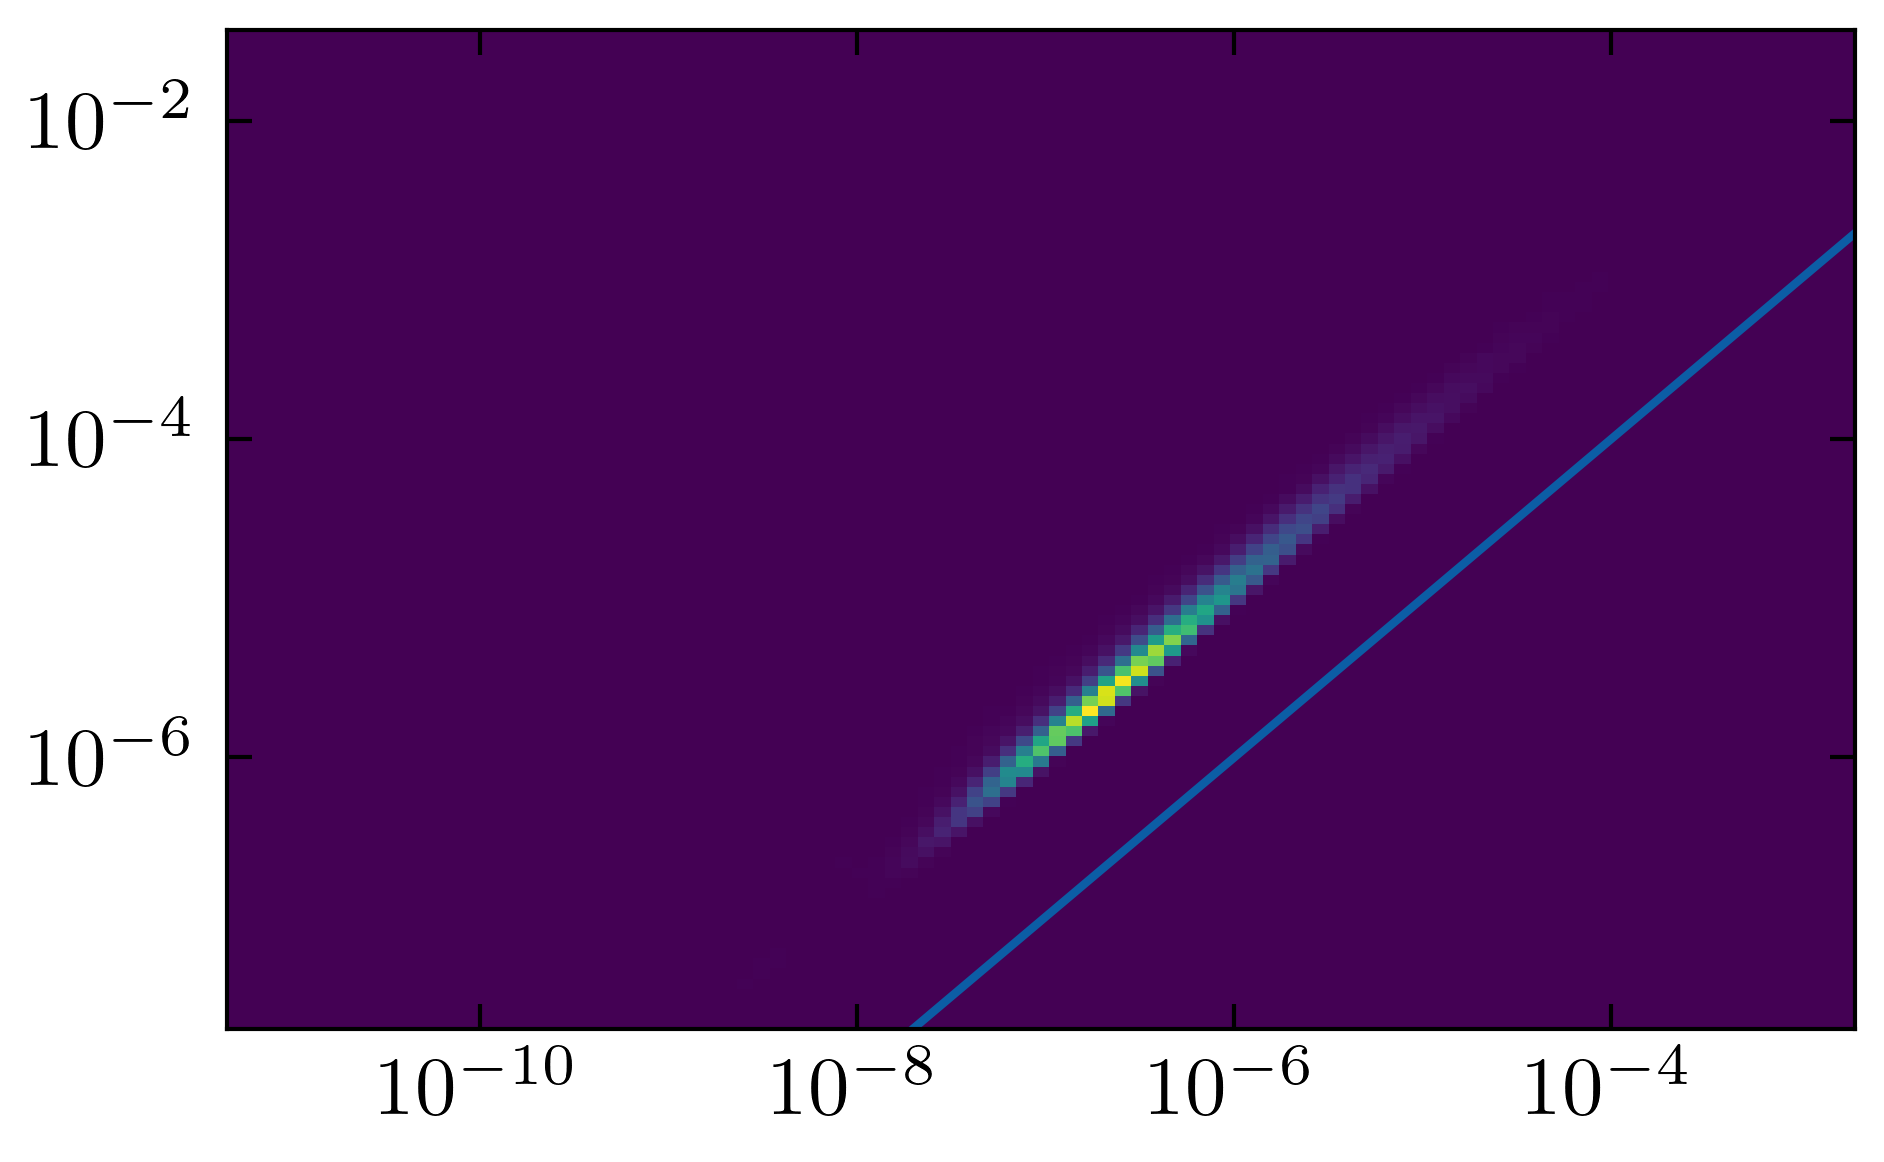

In [ ]:
agg_data = dp.boulder_agg_data.collect().filter(pl.col("longest_axis_diameter") != 0)

surface_area = agg_data["surface_area"].to_numpy()
circ_surface_area = 4 * np.pi * (agg_data["longest_axis_diameter"].to_numpy()) ** 2

surface_area = surface_area[surface_area < 1]
circ_surface_area = circ_surface_area[circ_surface_area < 1]

xbins = np.geomspace(surface_area.min(), surface_area.max(), 100)
ybins = np.geomspace(circ_surface_area.min(), circ_surface_area.max(), 100)

plt.hist2d(surface_area, circ_surface_area, [xbins, ybins])
plt.plot(xbins, xbins ** 1)
plt.xscale("log")
plt.yscale("log")

0.07951156


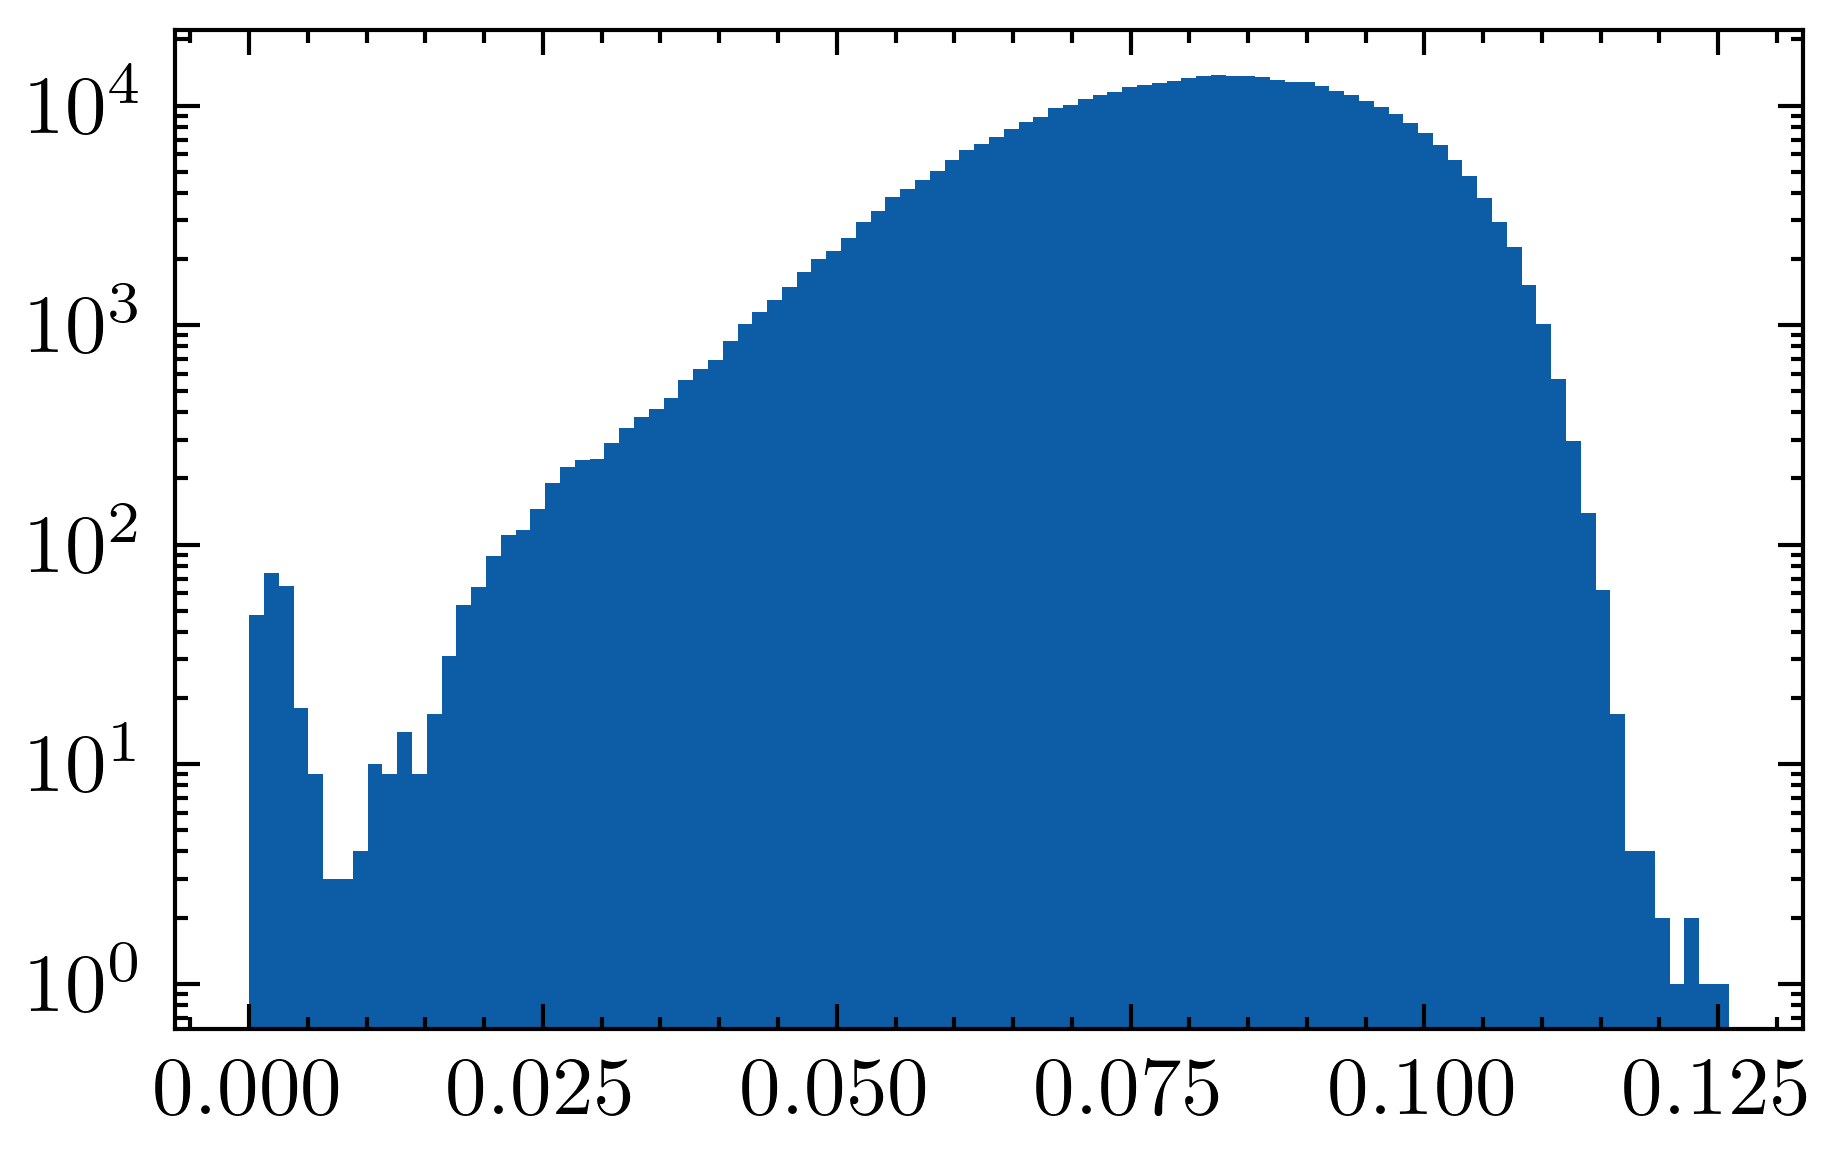

In [ ]:
agg_data = dp.boulder_agg_data.collect().filter(pl.col("longest_axis_diameter") != 0)

surface_area = agg_data["surface_area"].to_numpy()
circ_surface_area = 4 * np.pi * (agg_data["longest_axis_diameter"].to_numpy()) ** 2

ratios = surface_area / circ_surface_area
plt.hist(ratios, 100)
plt.yscale("log")

mean_rato = np.mean(ratios[(ratios < 1) & (ratios > 0)])
print(mean_rato)